In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(x, y, sigma, corr_length):
    """
    Compute the Gaussian kernel for two points (x, y) in 2D.
    """
    sqdist = np.sum((x - y) ** 2)
    return sigma ** 2 * np.exp(-sqdist / (2 * corr_length ** 2))

def kl_expand(grid_size, sigma, corr_length):
    """
    Generates multiple Gaussian random fields on a 2D grid using KL expansion.
    
    Parameters:
    grid_size : int - Size of the grid (grid_size x grid_size)
    sigma : float - Standard deviation of the Gaussian field
    corr_length : float - Correlation length of the Gaussian field
    kl_ndim : int - Number of KL expansion modes to retain
    num_samples : int - Number of random field samples to generate
    
    Returns:
    fields : 3D numpy array - The generated Gaussian random fields (num_samples x grid_size x grid_size)
    kl_values : 1D numpy array - The KL expansion eigenvalues (square root of the eigenvalues of the covariance matrix)
    kl_modes : 2D numpy array - The KL expansion modes (eigenvectors of the covariance matrix)
    """
    # Create a grid of points
    x = np.linspace(-2, 2, grid_size)
    y = np.linspace(-2, 2, grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.vstack([xx.ravel(), yy.ravel()]).T
    
    # Calculate the covariance matrix
    n_points = grid_size * grid_size
    cov_matrix = np.zeros((n_points, n_points))
    
    for i in range(n_points):
        for j in range(i, n_points):
            cov_matrix[i, j] = gaussian_kernel(points[i], points[j], sigma, corr_length)
            cov_matrix[j, i] = cov_matrix[i, j]
    
    # Perform eigenvalue decomposition
    w, v = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues and eigenvectors in descending order
    w = w[::-1]
    v = v[:, ::-1]
    
    # Select the first `kl_ndim` eigenvalues and eigenvectors
    kl_values = np.sqrt(np.abs(w))
    # print('Sum kl_value',sum(kl_values))
    # kl_values=kl_values[:kl_ndim]
    # print('Sum kl_value[:kl_dim]',sum(kl_values))
    # kl_modes = v[:, :kl_ndim]
    kl_modes = v[:, :]
    
    return kl_values, kl_modes

# Parameters
grid_size = 101       # Size of the grid (51x51)
sigma = 1.0          # Standard deviation of the Gaussian field
corr_length = 0.15   # Correlation length

# Generate the Gaussian random fields
kl_values, kl_modes= kl_expand(grid_size, sigma, corr_length)

In [59]:
def gradient_background(m, n, a, grand_v, delta_h):
    """
    # 示例参数
    m = 5  # 矩阵行数
    n = 4  # 矩阵列数
    a = 1  # 第一层速度
    grand_v = 0.5  # 梯度信息
    delta_h = 0.1  # 增量
    """
    v = np.arange(m) * delta_h * grand_v + a
    
    # 使用kron积扩展为m*n的矩阵
    matrix = np.kron(v.reshape(m, 1), np.ones((1, n)))

    return matrix

def generate_gaussian_random_fields(kl_values,kl_modes,kl_ndim, num_samples):  
    
    print('Sum kl_value',sum(kl_values))
    kl_values=kl_values[10:10+kl_ndim]
    print('Sum kl_value[:kl_dim]',sum(kl_values))
    kl_modes = kl_modes[:, 10:10+kl_ndim]
    z = np.random.randn(num_samples,kl_ndim)
    # 生成服从均匀分布的列
    gradient = np.random.uniform(0.03, 0.06, size=(num_samples, 1))
    # 将新的列添加到 z 的最后一列
    z = np.hstack((z, gradient))
    # Generate multiple samples using KL expansion
    fields = np.zeros((num_samples, grid_size, grid_size))
    for k in range(num_samples):
        # z = np.random.randn(kl_ndim)  # Independent standard normal variables
#         field = np.dot(kl_modes, kl_values * z[k,:])
        field = np.dot(kl_modes, z[k,:-1])
        background = gradient_background(grid_size, grid_size, 0, z[k,-1], 4/(grid_size-1))
        fields[k] = np.exp(field).reshape((grid_size, grid_size)) + background
#         
    return fields, z

kl_ndim = 20        # Number of KL expansion modes to retain
num_samples = 100000     # Number of random field samples to generate

fields, z = generate_gaussian_random_fields(kl_values,kl_modes,kl_ndim, num_samples)

# fields = 
# mean_trans = 1
# fields = mean_trans+1.5*mean_trans*fields/(fields.max()-fields.min())

print('fields_trans.min()',fields.min())
print('fields_trans.max()',fields.max())
print('fields_trans.mean()',fields.mean())

Sum kl_value 2242.16889508428
Sum kl_value[:kl_dim] 170.07983742844107
fields_trans.min() 0.7502301175874418
fields_trans.max() 1.4787114714286644
fields_trans.mean() 1.0909512418295522


## KL-modes

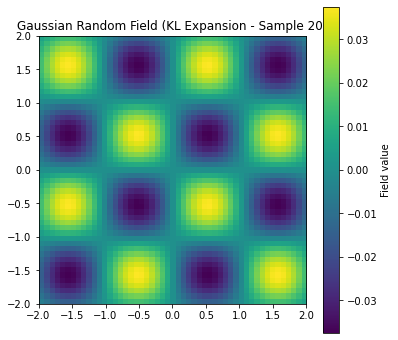

In [39]:
import time
from IPython.display import clear_output
for i in range(10,10+kl_ndim):
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(kl_modes[:,i].reshape(grid_size,grid_size), extent=(-2, 2, -2, 2), cmap='viridis')
    plt.colorbar(label='Field value')
    plt.title(f'Gaussian Random Field (KL Expansion - Sample {i+1})')
    plt.show()
    time.sleep(0.2)

## Gaussian feilds

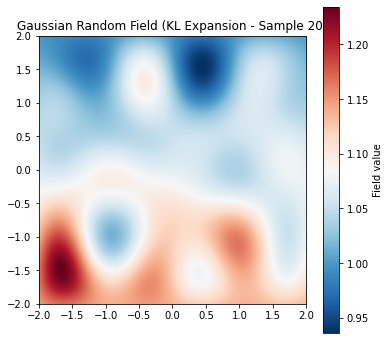

In [20]:
import time
from IPython.display import clear_output

# Plot the gaussian field 
for i in range(20):
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(fields[i], extent=(-2, 2, -2, 2), cmap='RdBu_r')
    plt.colorbar(label='Field value')
    plt.title(f'Gaussian Random Field (KL Expansion - Sample {i+1})')
    plt.show()
    time.sleep(0.2)



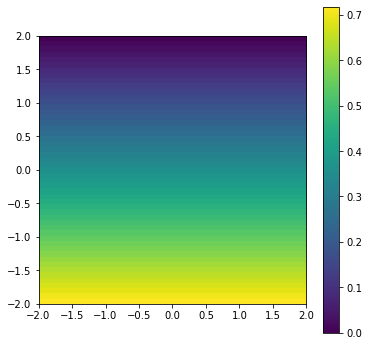

In [41]:
def gradient_background(m, n, a, grand_v, delta_h):
    """
    # 示例参数
    m = 5  # 矩阵行数
    n = 4  # 矩阵列数
    a = 1  # 第一层速度
    grand_v = 0.5  # 梯度信息
    delta_h = 0.1  # 增量
    """
    v = np.arange(m) * delta_h * grand_v + a

    
    # 使用矩阵积扩展为m*n的矩阵
    matrix = v.reshape(m, 1) @  np.ones((1, n))

    return matrix

background = gradient_background(grid_size, grid_size, 0, z[0,-1], 4/(grid_size-1))
plt.figure(figsize=(6, 6))

plt.imshow(background, extent=(-2, 2, -2, 2), cmap='viridis')
plt.colorbar()
plt.show()


In [60]:
import numpy as np
import skfmm
import matplotlib.pyplot as plt
from tqdm import trange
from scipy.ndimage import distance_transform_edt as distance

def Eikonal(F_sample,initial_point, delta,plt_show = False):

    # 速度函数，这里我们假定F恒等于1
    F = F_sample

    # F_value = F_value.reshape(10,10)
    # assign_to_submatrices(F[:,:], F_value)
    

    # 初始化行进时间T
    T = np.full_like(F_sample, np.inf)

    # 初始点在(0,0)处，我们需要计算这一点在网格中的索引
    # initial_index = (np.where(y == initial_point[1])[0], np.where(x == initial_point[0])[0])
    initial_index = (np.where(y == initial_point[1])[0], np.where(x == initial_point[0])[0])
    # initial_index = (np.where(XY=

    # 设置初始点的行进时间为0
    T[initial_index] = 0

    # 边界处理，由于Eikonal方程通常需要边界条件，我们假定域的边界是不可达的
    # 使用ndimage中的distance_transform_edt来设置边界条件：
    mask = np.ones_like(F_sample, dtype=bool)
    mask[initial_index] = False
    phi = -distance(mask) + distance(~mask)
    T = np.ma.MaskedArray(T, mask)

    # 计算行进时间
    T = skfmm.travel_time(phi, F , dx=delta)
    if plt_show == True:
        plt.imshow(T,interpolation='none',extent=[-2, 2, -2, 2], cmap='RdBu_r', aspect='equal', vmin=0)
        plt.plot(initial_point[0],initial_point[1], 'wo')  # 初始点标记为白色圆圈
        plt.colorbar(label='Travel time')
        plt.show()

    # 提取右侧值
    # T_0 = T[0,0:mesh_x:5].reshape(1,-1) #Top
    # T_1 = T[-1,0:mesh_x:5].reshape(1,-1) #Bottom
    # T_2 = T[5:mesh_x-5:5,0].reshape(1,-1) #Left
    # T_3 = T[5:mesh_x-5:5,-1].reshape(1,-1) #Right
    # T_coarse = np.concatenate([T_0,T_1,T_2,T_3],axis=1)

    # return T_coarse.reshape(1,-1)
    return T


########################################################
# 定义域，这里我们使用一个不均匀的网格，因为y轴的范围从0到-4，x从-2到2
mesh_x = grid_size
mesh_y = grid_size
delta = 4/(grid_size-1)
x = np.linspace(-2, 2, mesh_x)
y = np.linspace(2, -2, mesh_y)
X, Y = np.meshgrid(x, y)

N_sample = num_samples

# F2_sample = np.random.uniform(0.5,1.5,[N_sample,10*10])



T_time = np.zeros([N_sample,grid_size,grid_size])
# T_time = np.zeros([N_sample,4*(mesh_x//5)])

# initial_point = np.array([[-2,0],[-2,-0.5],[-2,-1],
#                           [-2,-1.5],[-2,-2],[-2,-2.5],
#                           [-2,-3],[-2,-3.5],[-2,-4]])
initial_point = np.array([0,0])

pbar = trange(N_sample)
for i in range(N_sample):
    clear_output(wait=True)
    F_sample = fields[i]
    T_time[i] = Eikonal(F_sample,initial_point, delta,plt_show = False)
    if i%(N_sample/10)==0:
        print(f"{i}/{N_sample} sample have been generated")
    # time.sleep(0.2)
    


##########################################################

# np.savetxt('./data/T_time.txt', T_time)
# np.savetxt('./data/block_para.txt', block_para)

print('all done')


all done


In [52]:
for i in range(T_time.shape[1]):
    clear_output(wait=True)
    print(T_time[:,:,i].var())
    time.sleep(0.2)

0.08098177268691457


KeyboardInterrupt: 

In [57]:
T_time.shape

(10000, 101, 101)

In [58]:
np.savez('kl_data_grad.npz', kl_values=kl_values[10:10+kl_ndim], kl_modes=kl_modes[:, 10:10+kl_ndim],kl_z=z,T_time=T_time, v_fields = fields)

In [61]:
np.savez('kl_data_grad_10w.npz', kl_values=kl_values[10:10+kl_ndim], kl_modes=kl_modes[:, 10:10+kl_ndim],kl_z=z,T_time=T_time, v_fields = fields)

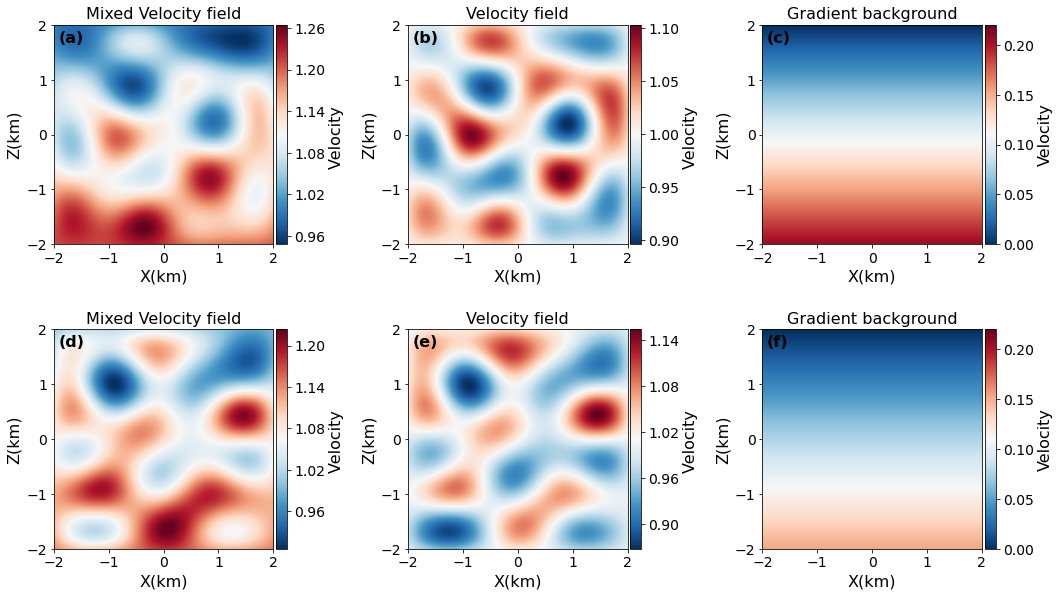

In [122]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator

font_size = 16

plt.rcParams.update({
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size - 2,
    'ytick.labelsize': font_size - 2,
    'legend.fontsize': font_size,
    'figure.titlesize': font_size
})

def gradient_background(m, n, a, grand_v, delta_h):
    """
    # 示例参数
    m = 5  # 矩阵行数
    n = 4  # 矩阵列数
    a = 1  # 第一层速度
    grand_v = 0.5  # 梯度信息
    delta_h = 0.1  # 增量
    """
    v = np.arange(m) * delta_h * grand_v + a

    
    # 使用矩阵积扩展为m*n的矩阵
    matrix = v.reshape(m, 1) @  np.ones((1, n))

    return matrix

fig, axs = plt.subplots(2,3,figsize=[15,10])

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']  # 每个子图的标签
label_x,label_y = 0.02, 0.92


i=0

ax=axs[0,0]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
im = ax.imshow(fields[i], extent=(-2, 2, -2, 2), cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Mixed Velocity field')
ax.text(label_x, label_y, labels[0], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity ')  
cbar.set_ticks([0.95,1.05,1.15,1.25])
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()  # 更新刻度显示

ax=axs[0,2]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
background = gradient_background(grid_size, grid_size, 0, z[i,-1], 4/(grid_size-1))
im = ax.imshow(background, extent=(-2, 2, -2, 2),vmax=0.22, cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Gradient background')
ax.text(label_x, label_y, labels[2], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity')  # 可选：为颜色条添加标签
# cbar.set_ticks([0,0.05,0.1,0.15,0.2])
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()  # 更新刻度显示

ax=axs[0,1]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
im = ax.imshow(fields[i]-background, extent=(-2, 2, -2, 2), cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Velocity field')
ax.text(label_x, label_y, labels[1], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity ') 
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()  # 更新刻度显示
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()  # 更新刻度显示
 
i=10

ax=axs[1,0]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
im = ax.imshow(fields[i], extent=(-2, 2, -2, 2), cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Mixed Velocity field')
ax.text(label_x, label_y, labels[3], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity ')  
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()  # 更新刻度显示
 





ax=axs[1,2]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
background = gradient_background(grid_size, grid_size, 0, z[i,-1], 4/(grid_size-1))
im = ax.imshow(background, extent=(-2, 2, -2, 2),vmax=0.22, cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Gradient background')
ax.text(label_x, label_y, labels[5], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity')  # 可选：为颜色条添加标签
# cbar.set_ticks([0,0.05,0.1,0.15])
cbar.set_ticks([0,0.05,0.1,0.15,0.2])
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()  # 更新刻度显示
 
ax=axs[1,1]
ax.set_xticks([-2, -1, 0, 1, 2])  # X轴刻度
ax.set_yticks([-2, -1, 0, 1, 2])  # Y轴刻度
im = ax.imshow(fields[i]-background, extent=(-2, 2, -2, 2),cmap='RdBu_r')
# 设置轴标签和图表标题
ax.set_xlabel('X(km)')
ax.set_ylabel('Z(km)')
ax.set_title('Velocity field')
ax.text(label_x, label_y, labels[4], transform=ax.transAxes, fontsize=16,fontweight='bold', color='black')
# 显示颜色条
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.04)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Velocity ')  
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()  # 更新刻度显示
 

plt.tight_layout()
plt.subplots_adjust(hspace=-0.1)
plt.show()
fig.savefig(".../figures/sec2_velocity_fields.pdf")